Binary Text Classification with IMDB Dataset:

In [ ]:
# Load and preprocess data

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_words = 10_000

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(
    num_words=num_words
)

print(len(x_train_full), len(x_test))
print(x_train_full[0][:20])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 25000
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


In [ ]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

x_train_full = vectorize_sequences(x_train_full, num_words)
x_test = vectorize_sequences(x_test, num_words)

y_train_full = np.asarray(y_train_full).astype("float32")
y_test = np.asarray(y_test).astype("float32")

print(x_train_full.shape)
print(x_test.shape)

(25000, 10000)
(25000, 10000)


In [ ]:
# Train and validation split

x_val = x_train_full[:10_000]
partial_x_train = x_train_full[10_000:]

y_val = y_train_full[:10_000]
partial_y_train = y_train_full[10_000:]

print(partial_x_train.shape)
print(x_val.shape)

(15000, 10000)
(10000, 10000)


In [ ]:
# # Build the model

# model = keras.Sequential([
#     layers.Dense(16, activation="relu", input_shape=(num_words,)),
#     layers.Dense(16, activation="relu"),
#     layers.Dense(1, activation="sigmoid")
# ])

# model.compile(
#     optimizer="rmsprop",
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

# model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # Train the model

# history = model.fit(
#     partial_x_train,
#     partial_y_train,
#     epochs=30,
#     batch_size=512,
#     validation_data=(x_val, y_val)
# )

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9972 - loss: 0.0180 - val_accuracy: 0.8701 - val_loss: 0.5624
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9976 - loss: 0.0166 - val_accuracy: 0.8690 - val_loss: 0.5920
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9991 - loss: 0.0101 - val_accuracy: 0.8636 - val_loss: 0.6360
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9976 - loss: 0.0140 - val_accuracy: 0.8674 - val_loss: 0.6304
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9999 - loss: 0.0068 - val_accuracy: 0.8676 - val_loss: 0.6486
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9994 - loss: 0.0094 - val_accuracy: 0.8674 - val_loss: 0.6682
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9979 - loss: 0.0107 - val_accuracy: 0.8672 - val_loss: 0.6959
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9999 - loss: 0.0043 - val_accuracy: 0.8672 - v

In [ ]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=3,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6775 - loss: 0.6066 - val_accuracy: 0.8543 - val_loss: 0.4586
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8325 - loss: 0.4248 - val_accuracy: 0.8765 - val_loss: 0.3286
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.8785 - loss: 0.3284 - val_accuracy: 0.8805 - val_loss: 0.3017


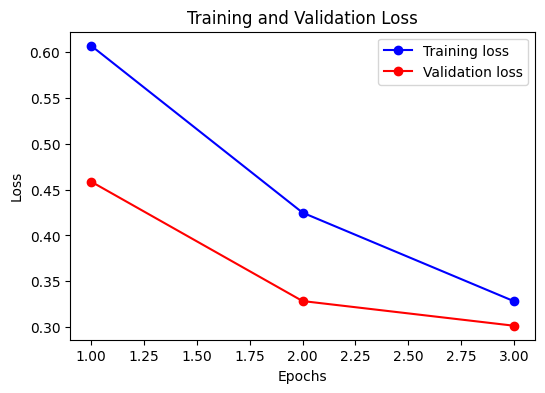

In [ ]:
# Plot loss and accuracy

history_dict = history.history

loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

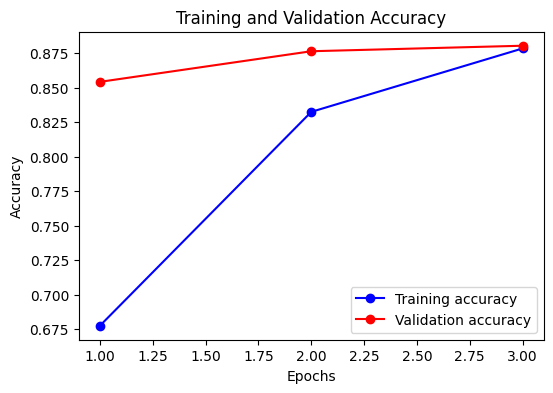

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(epochs, accuracy, "bo-", label="Training accuracy")
plt.plot(epochs, val_accuracy, "ro-", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

The training and validation loss decreased during the first epochs, showing that the model learned useful patterns from the data.

The validation loss reached its minimum around epoch 3 and then started to increase slightly, which indicates the beginning of overfitting. At the same time, validation accuracy stabilized around 88–89%.

The gap between training and validation accuracy remained small, showing that the model generalizes well.

Therefore, the optimal number of epochs is around 3.